# Compare performance on different splits

Two new splits were created: 
- `asl100_bottom`: 100 classes with fewest examples. See this [notebook.](./100_fewest.ipynb) 
- `asl100_worst`: 100 classes with the worst f1-score from the at-the-time best model. See this [notebook.](./100_worst.ipynb)


In [1]:

from pathlib import Path
from typing import List, Any
from pydantic import BaseModel
import pandas as pd
import json
import logging
import numpy as np
import matplotlib.pyplot as plt
# locals
from src.resulting import (
    print_json,
    RESULTS_DIR,
    load_config_and_find_runs,
    load_config,
    find_runs,
    basic_logger,
    modify,
    snap
)
from src.run_types import GenInfo
from src.stats import (
    AVAIL_SETS,
    AVAIL_SPLITS,
)
from src.visualise import get_all_sets, FrameVisualiser, printv
from src.models import avail_models
from src.configs import get_config_path


Please update your PyTorchVideo to latest master


## Setup:

Set variables for dataset loading

In [ ]:
# all_classes = get_class_list()

verbosity = 1
save_files = False
split_idx = 0 #change for different split
set_idx = 0 #change for different set
split_options: List[AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000", 'asl100_bottom', 'asl100_worst']
set_options: List[AVAIL_SETS] = ['train', 'test', 'val']
split_name: AVAIL_SPLITS = split_options[split_idx]
set_name: AVAIL_SETS = set_options[set_idx]
cls_index = 60
# all_classes = get_class_list()
all_sets = get_all_sets(split_name, verbosity=verbosity)
frame_viewer = FrameVisualiser(
    cls_index,
    all_sets,
    set_name,
    split_name,
    verbosity=verbosity
)
print_v = printv(verbosity)

### Frame viewer

See example frames

From: asl100S/train
Example videos for class: "doctor"
Instance: 5/13
Next example video path: /home/luke/Code/SLR/data/WLASL/WLASL2000/17017.mp4


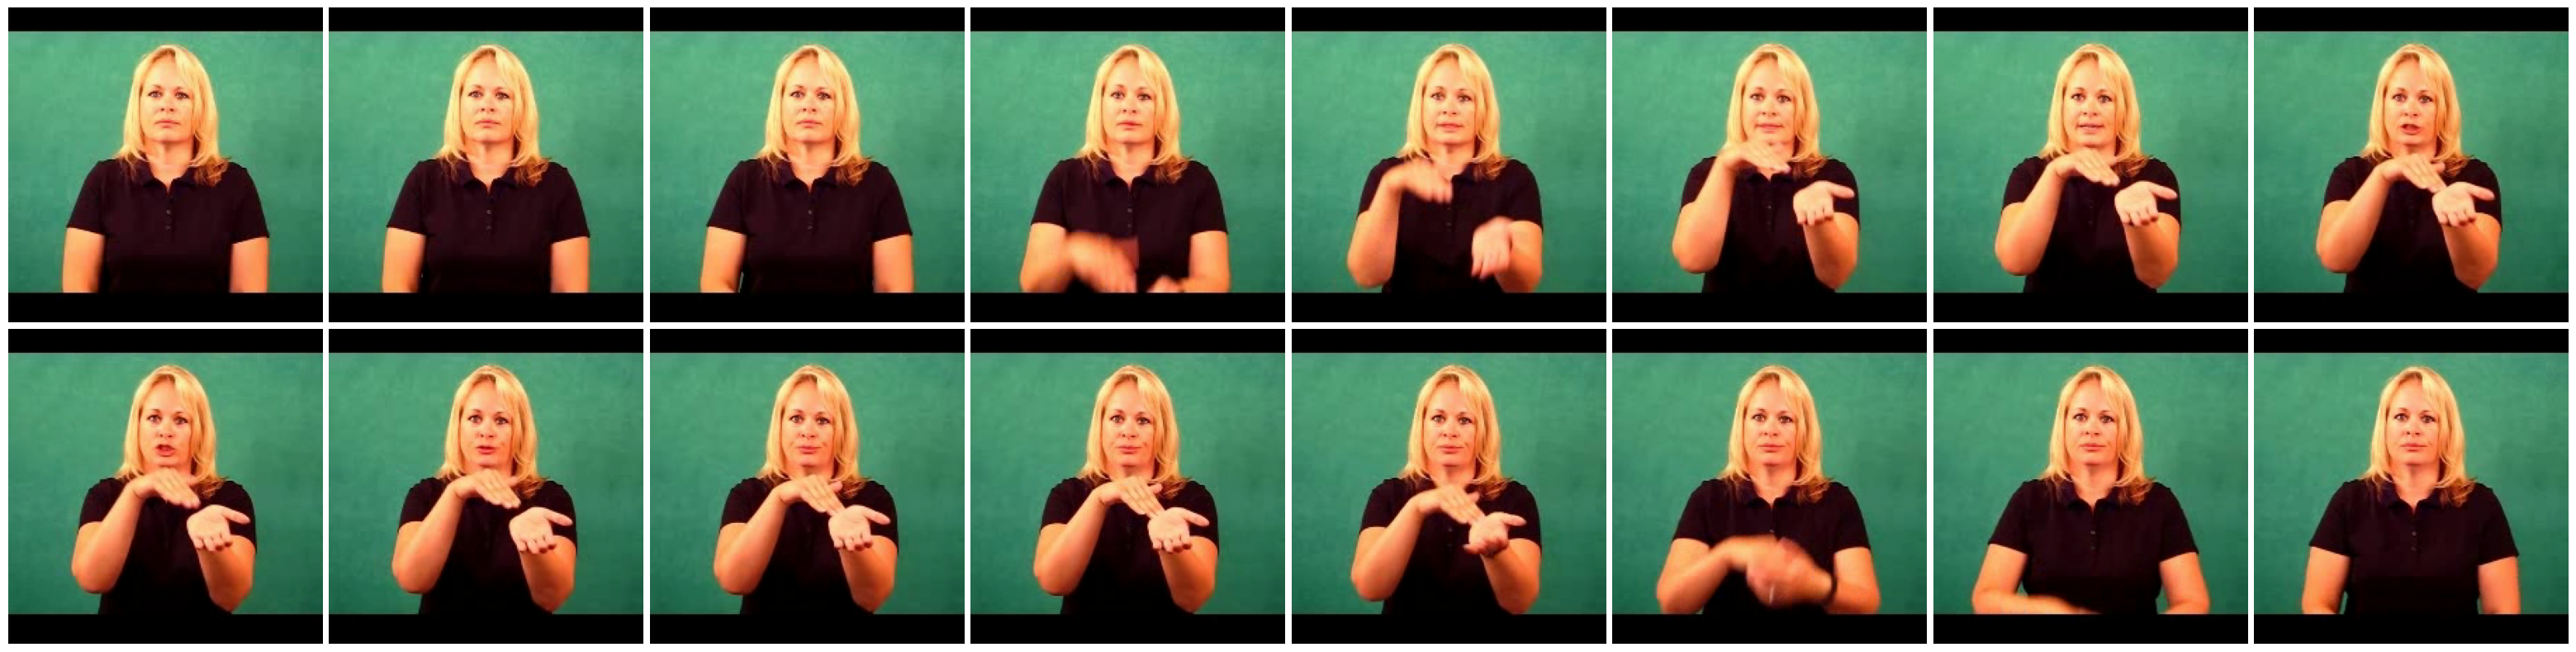

In [13]:
frame_viewer()

### Specifications of experiment

Use the provided path to load a config file, runs are matched against the specification

In [4]:
acc_cuttoff = 0
chosen_models = avail_models()
chosen_splits : list[AVAIL_SPLITS] = ['asl100', 'asl100_bottom', 'asl100_worst']

additional_modifications = {
    # 'results': {
    #     'best_val_acc': lambda x: x > acc_cuttoff
    # },
    # 'admin': {
    #     'model': lambda x: x in avail_models,
    #     # 'split': lambda x: x in avail_splits
    # }
    
    
}

def drop_max_wobble(temporal_aug: list) -> list:
    for item in temporal_aug:
        item.pop('max_wobble', None)
    return temporal_aug

ignore_keys = {
    'data': {
        'train_augs': {'temporal_aug': drop_max_wobble},
        'test_augs':  {'temporal_aug': drop_max_wobble},
    }
}


exclude_keys = [
    ['results', 'test_shuff'],
    ['results', 'check_name'],
]

def load_find(conf_path: Path) -> GenInfo:
    runs =  load_config_and_find_runs(
            conf_path,
            exclude=exclude_keys,
            extra_mods=additional_modifications,
            logging_level=logging.INFO
        )
    assert runs is not None, 'No runs found'
    return runs

In [5]:
# conf_path = Path('configfiles/asl100/MViTv2_S/exp016.toml')
conf_path = get_config_path(
    split='asl100',
    model='MViTv2_S',
    exp_no=16,
)
assert conf_path.exists()
config = load_config(str(conf_path))
# print_json(modify(config, ignore_keys, basic_logger))

## Matched runs:

Two runs on `asl100` for control, and then the runs on `asl100_worst` and `asl100_bottom`. 

In [6]:
runs = load_find(conf_path)
# for run in runs['results']:
#     print_json(run['admin'])
#     print()
print(len(runs['results']))

Loaded que state from /home/luke/Code/SLR/src/que/Runs.json
Found 4/166 runs matching the spec
Excluded 0 runs based on additional modifications


4


## Comparing results

We take the mean of the two run on `asl100` and each of the runs on the custom bad sets.

In [7]:
avail_acc_types = ["top_k_average_per_class_acc", "top_k_per_instance_acc"]
acc_type = avail_acc_types[1]
set_name = 'test'

df_format = []

mvit_average = {'top1': 0, 'top2': 0, 'top3': 0}
num_mvit = 0
li = []
for i, res in enumerate(runs['results']): 
    model_name = res['admin']['model']
    split = res['admin']['split']
    if split == 'asl100':
        mvit_average = {k : v + v2 for (k,v), v2 in zip(res['results'][set_name][acc_type].items(), mvit_average.values())} 
        num_mvit += 1
        li.append(i)

df_format.append({'model': 'MViTv2_S', 'subset': 'asl100_mean'} | {k : v / num_mvit for k, v in mvit_average.items()})

for res in runs['results']: 
    model_name = res['admin']['model']
    split = res['admin']['split']
    if split =='asl100':
        continue
    df_format.append(
        {'model': model_name, 'subset': split} | {k : v for k, v in res['results'][set_name][acc_type].items()}
    )


df = pd.DataFrame(df_format)
df = df.rename(columns={"top1": "Top-1", "top5": "Top-5", "top10": "Top-10"})
df['Top-1'] = df['Top-1'].apply(lambda x: f'{x*100:.2f}')
df['Top-5'] = df['Top-5'].apply(lambda x: f'{x*100:.2f}')
df['Top-10'] = df['Top-10'].apply(lambda x: f'{x*100:.2f}')

display(df.sort_values('Top-1', ascending=False))

,model,subset,Top-1,Top-5,Top-10
0,MViTv2_S,asl100_mean,79.65,93.41,96.12
2,MViTv2_S,asl100_bottom,60.00,86.00,92.00
1,MViTv2_S,asl100_worst,55.66,83.49,90.09


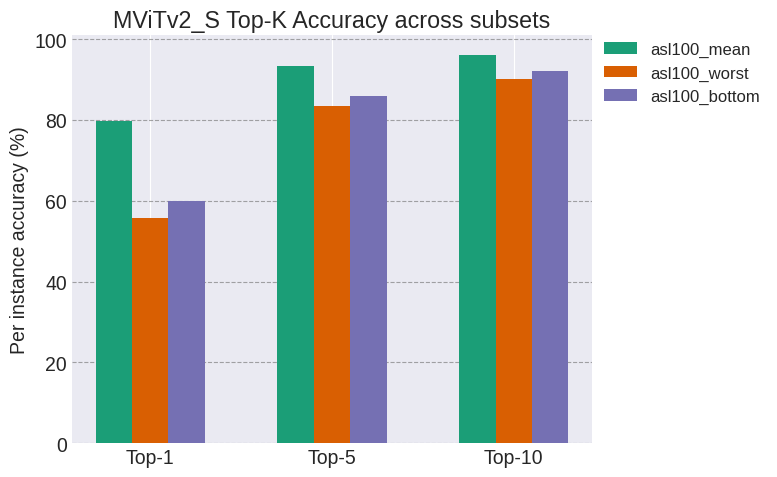

In [22]:
plt.rcParams.update({'font.size': 14}) # Font

subsets = df['subset'].unique()
metrics = ['Top-1', 'Top-5', 'Top-10']
df[metrics] = df[metrics].astype(float)
x = np.arange(len(metrics))
width = 0.2  # bar width

fig, ax = plt.subplots(figsize=(8, 5))

cmap = plt.get_cmap('Dark2')



for i, subset in enumerate(subsets):
    row = df[df['subset'] == subset][metrics].mean()
    ax.bar(x + i * width, row, width, label=subset, color=cmap(i))



ax.set_xticks(x + width * (len(subsets) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylabel('Per instance accuracy (%)')
ax.set_title('MViTv2_S Top-K Accuracy across subsets')
ax.legend(fontsize=12, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()  # prevents the legend from being clipped
ax.set_axisbelow(True)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, color='gray', zorder=0)
plt.savefig("outputs/different_100s.pdf", dpi=150, bbox_inches='tight')
plt.show()